In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import shap
from sklearn.tree import export_text

c:\Users\myahy\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Load Data and Encoders (from Notebook 3)

In [2]:
X_test = pd.read_csv("../dataset/X_test.csv")
y_test = pd.read_csv("../dataset/y_test.csv").squeeze()
label_encoder = joblib.load("../models/label_encoder.pkl")
crop_names = label_encoder.classes_

print("--- 1. Agronomist Rule Extraction ---")

--- 1. Agronomist Rule Extraction ---


# 2. Extract Human-Readable Rules from the Decision Tree

In [3]:
# We specifically use the Decision Tree because it trained on unscaled, raw data
dt_model = joblib.load("../models/DecisionTree.pkl")

# Extract the logic rules
tree_rules = export_text(dt_model, feature_names=list(X_test.columns))

# Save rules to a text file for agricultural experts to review
with open("../reports/agronomist_rules.txt", "w") as f:
    f.write(tree_rules)
    
print("Decision Tree 'If-Else' rules successfully saved to '../reports/agronomist_rules.txt'")
# Tip: Open this file to see rules like "if rainfall <= 95.00 and humidity > 80.00..."


print("\n--- 2. Explainable AI (SHAP) ---")

Decision Tree 'If-Else' rules successfully saved to '../reports/agronomist_rules.txt'

--- 2. Explainable AI (SHAP) ---


# 3. Load the best tree-based model for SHAP (Assuming RandomForest or XGBoost won)

In [4]:
# We use tree-based models here because they preserve the original unscaled units
best_model = joblib.load("../models/RandomForest.pkl") 

# Initialize the SHAP Tree Explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# A. Global Interpretability: Multi-Class Summary Bar Plot

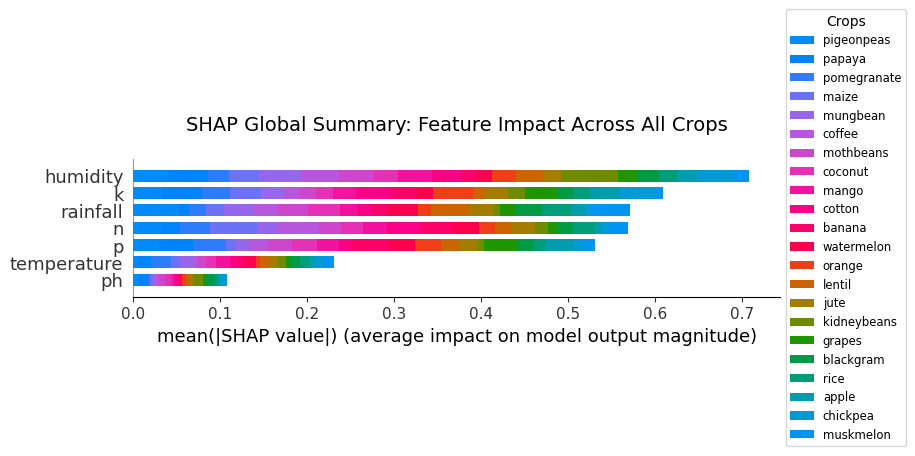

Saved SHAP Global Summary Plot.


In [5]:
plt.figure(figsize=(14, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=crop_names, show=False)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Crops", fontsize='small')

plt.title("SHAP Global Summary: Feature Impact Across All Crops", fontsize=14, pad=20)
plt.savefig("../reports/shap_global_summary.png", dpi=300, bbox_inches='tight')
plt.show()

print("Saved SHAP Global Summary Plot.")

# B. Local Interpretability: Explain a Single Crop's Decisions (e.g., 'Rice')

Saved SHAP Explanation for 'Rice'.

Research pipeline execution complete. Check the '/reports' folder for paper-ready assets.


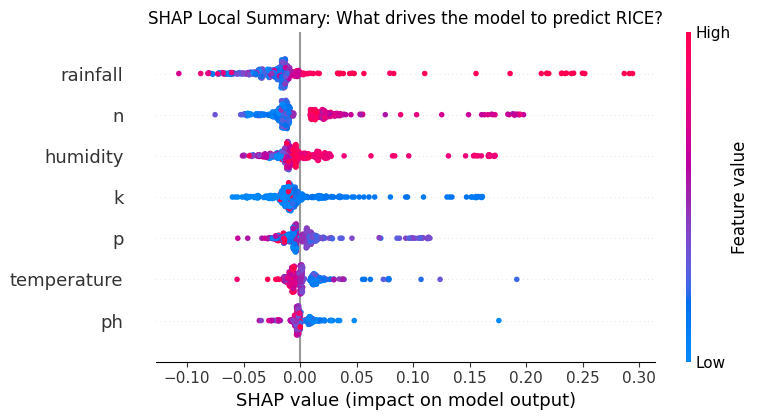

In [6]:
# Let's say 'rice' is class index 20 (you can check your label_encoder classes)
rice_index = list(crop_names).index('rice')
rice_shap_values = shap_values[rice_index] if isinstance(shap_values, list) else shap_values[:, :, rice_index]

plt.figure(figsize=(10, 6))
shap.summary_plot(rice_shap_values, X_test, show=False)
plt.title("SHAP Local Summary: What drives the model to predict RICE?")
plt.tight_layout()
plt.savefig("../reports/shap_rice_explanation.png", dpi=300)
print("Saved SHAP Explanation for 'Rice'.")

print("\nResearch pipeline execution complete. Check the '/reports' folder for paper-ready assets.")